# Statistik mit Python – Grundlagen

Dieses Notebook führt in die wichtigsten statistischen Grundbegriffe ein und zeigt,
wie man sie mit Python (pandas, numpy, matplotlib, seaborn) berechnet und visualisiert.

Wir arbeiten mit:
- kleinen Beispiel-Datensätzen
- realen Daten (z. B. Housing‑Data)
- klaren Definitionen
- Schritt‑für‑Schritt‑Erklärungen

Ziel: Statistik verstehen UND praktisch anwenden.

# 🧪 0. Dictionary, Beispiel-Datensätze und Funktionen

In [38]:
statistik = {
    "arith_mittel": "Summe aller Werte geteilt durch Anzahl der Werte",
    "varianz": "Durchschnittliche quadratische Abweichung vom Mittelwert",
    "standardabweichung": "Wurzel der Varianz",
    "median": "Zentralwert einer sortierten Verteilung",
    "modus": "Häufigster Wert",
    "korrelation": "Stärke des linearen Zusammenhangs zweier Variablen",
    "regression": "Modellierung eines funktionalen Zusammenhangs",
}

In [71]:
formeln = {
    "spannweite": "max(x) - min(x)",
    "mittlere_abs_abweichung": "Durchschnitt der |xi - Median|",
    "variationskoeffizient": "Standardabweichung / Mittelwert",
    "gini_normiert": "G / (n-1)",
    "kontingenzkoeffizient": "sqrt(chi2 / (chi2 + n))",
    "spearman": "1 - (6 * sum(d_i^2)) / (n*(n^2-1))",
    "laspeyres_preisindex": "sum(pi_t * qi_0) / sum(pi_0 * qi_0)",
    "paasche_preisindex": "sum(pi_t * qi_t) / sum(pi_0 * qi_t)",
    "wachstumsrate": "(Xt - Xt-1) / Xt-1",
    "wachstumsfaktor": "Xt / Xt-1",
    "messzahl": "Xt / X0",
    "hypergeom": "comb(M, x) * comb(N-M, n-x) / comb(N, n)",
}

In [60]:
import pandas as pd

sns.set(style="whitegrid")

# Beispiel-Datensatz (synthetisch, damit alles funktioniert)
np.random.seed(42)

df = pd.DataFrame({
    "Wert": np.random.normal(loc=50, scale=10, size=300),
    "GrLivArea": np.random.normal(loc=1500, scale=300, size=300),
    "SalePrice": np.random.normal(loc=200000, scale=40000, size=300),
    "OverallQual": np.random.randint(1, 10, size=300),
    "KitchenQual": np.random.choice(["TA","Gd","Ex","Fa"], size=300),
    "YrSold": np.random.randint(2006, 2010, size=300)
})

df.head()

,Wert,GrLivArea,SalePrice,OverallQual,KitchenQual,YrSold
0,54.967142,1251.301497,230279.544666,2,Gd,2006
1,48.617357,1331.945688,163113.387033,4,TA,2008
2,56.476885,1724.188082,234784.236804,2,TA,2008
3,65.230299,1683.111080,254225.514352,7,Ex,2009
4,47.658466,1493.729522,216537.396129,2,Fa,2009


In [73]:
# Qualitative Merkmale
# Häufigkeitstabellen, Gruppierung, Pivot‑Tabellen

def haeufigkeiten_qualitativ(series):
    df = pd.DataFrame({
        "absolut": series.value_counts(),
        "relativ": series.value_counts(normalize=True),
        "relativ_%": series.value_counts(normalize=True) * 100
    })
    return df

def gruppieren(series, mapping):
    """mapping = dict: alte Ausprägung → neue Gruppe"""
    return series.map(mapping)

In [74]:
# Qualitative Merkmale
Klassierung, Histogramme, Summenhäufigkeiten
def klassieren(series, k):
    return pd.cut(series, bins=k)

def summenhäufigkeit(series):
    abs_h = series.value_counts().sort_index()
    kum_abs = abs_h.cumsum()
    kum_rel = kum_abs / kum_abs.iloc[-1]
    return pd.DataFrame({"abs": abs_h, "kum_abs": kum_abs, "kum_rel": kum_rel})

# 📈 2. Lagemaße

# 📊 1. Häufigkeiten

## 1.1 Absolute und relative Häufigkeiten

In [75]:
import pandas as pd

daten = ["rot","blau","rot","grün","gelb","blau","rot","gelb","grün","blau",
         "rot","rot","gelb","grün","blau","grün","rot","blau","blau","rot"]

df = pd.DataFrame(daten, columns=["Farbe"])
absolute = df["Farbe"].value_counts()
relative = df["Farbe"].value_counts(normalize=True)

haeufigkeitstabelle = pd.DataFrame({
    "absolut": absolute,
    "relativ": relative,
    "relativ_%": relative * 100
})

haeufigkeitstabelle

,absolut,relativ,relativ_%
Farbe,,,
rot,7,0.35,35.0
blau,6,0.30,30.0
grün,4,0.20,20.0
gelb,3,0.15,15.0


# 📐 2. Lagemaße & Streuung

## 2.1 Mittelmaße, Median, Modus, Spannweite, Quantile, Abweichung, Variationskoeffizient

In [78]:
import numpy as np
from scipy import stats

def arith_mittel(x):
    return np.mean(x)

def geom_mittel(x):
    return np.prod(x)**(1/len(x))

def harm_mittel(x):
    return len(x) / np.sum(1/x)

def median(x):
    return np.median(x)

def quantil(x, p):
    return np.quantile(x, p)

def spannweite(x):
    return np.max(x) - np.min(x)

def mittlere_abs_abweichung(x):
    med = np.median(x)
    return np.mean(np.abs(x - med))

def variationskoeff(x):
    return np.std(x, ddof=1) / np.mean(x)

    print("Arithmetisches Mittel:", arith_mittel(werte))
print("Geometrisches Mittel:", geom_mittel(werte))
print("Harmonisches Mittel:", harm_mittel(werte))
print("Median:", median(werte))
print("0.25-Quantil:", quantil(werte, 0.25))
print("Spannweite:", spannweite(werte))
print("Mittlere absolute Abweichung:", mittlere_abs_abweichung(werte))
print("Variationskoeffizient:", variationskoeff(werte))

Geometrisches Mittel: 4.85377122695035
Harmonisches Mittel: 4.387950548493818
Median: 5.0
0.25-Quantil: 4.0
Spannweite: 7
Mittlere absolute Abweichung: 1.7
Variationskoeffizient: 0.4176593136071445


## 2.2 Varianz & Standardabweichung

In [42]:
varianz = np.var(werte, ddof=0)
std = np.std(werte, ddof=0)

varianz, std

(np.float64(4.41), np.float64(2.1))

## 2.3 Gini‑Koeffizient

In [43]:
def gini(x):
    x = np.sort(x)
    n = len(x)
    return (2*np.sum((np.arange(1,n+1)*x)))/(n*np.sum(x)) - (n+1)/n

gini(werte)

np.float64(0.2245283018867923)

# 📉 3. Zeitreihen & Wachstumsraten

## 3.1 Wachstumsrate & Wachstumsfaktor

In [44]:
umsatz = np.array([100,120,150,180,210])

wachstumsraten = (umsatz[1:] - umsatz[:-1]) / umsatz[:-1]
wachstumsfaktoren = umsatz[1:] / umsatz[:-1]

wachstumsraten, wachstumsfaktoren

(array([0.2       , 0.25      , 0.2       , 0.16666667]),
 array([1.2       , 1.25      , 1.2       , 1.16666667]))

## 3.2 Gleitende Durchschnitte

In [45]:
def gleitender_durchschnitt(x, k):
    return np.convolve(x, np.ones(k)/k, mode="valid")

gleitender_durchschnitt(umsatz, 3)

array([123.33333333, 150.        , 180.        ])

## 3.3 Exponentielle Glättung

In [46]:
def exp_glättung(x, alpha):
    result = [x[0]]
    for t in range(1, len(x)):
        result.append(alpha*x[t] + (1-alpha)*result[-1])
    return np.array(result)

exp_glättung(umsatz, alpha=0.3)

array([100.   , 106.   , 119.2  , 137.44 , 159.208])

# 📐 4. Regression & Korrelation

## 4.1 Lineare Regression

In [47]:
from sklearn.linear_model import LinearRegression

X = np.array([160,192,175,178,185,158,169,182,172,165]).reshape(-1,1)
y = np.array([57,86,68,80,82,52,65,87,74,69])

model = LinearRegression()
model.fit(X, y)

a = model.intercept_
b = model.coef_[0]

a, b

(np.float64(-103.45360824742266), np.float64(1.0106774668630338))

## 4.2 Vorhersage

In [48]:
groesse = 175
gewicht_schaetzung = model.predict([[groesse]])[0]
gewicht_schaetzung

np.float64(73.41494845360825)

## 4.3 Pearson‑Korrelation

In [49]:
from scipy.stats import pearsonr

pearsonr(X.flatten(), y)

PearsonRResult(statistic=np.float64(0.9282170256740881), pvalue=np.float64(0.0001064520104411268))

## 4.4 Spearman‑Rangkorrelation

In [50]:
from scipy.stats import spearmanr

spearmanr(X.flatten(), y)

SignificanceResult(statistic=np.float64(0.9030303030303028), pvalue=np.float64(0.00034361219776328223))

# 🎲 5. Wahrscheinlichkeiten & Verteilungen

## 5.1 Kombinatorik

In [51]:
import math

# Lotto 6 aus 49
lotto = math.comb(49,6)
lotto

13983816

## 5.2 Binomialverteilung

In [52]:
from scipy.stats import binom

# Wahrscheinlichkeit für 3 Treffer bei p=0.3, n=10
binom.pmf(3, n=10, p=0.3)

np.float64(0.26682793199999977)

## 5.3 Hypergeometrische Verteilung

In [53]:
from scipy.stats import hypergeom

# Beispiel: N=50, M=5 Erfolge, n=10 Ziehungen
hypergeom.pmf(2, M=5, N=50, n=10)

np.float64(nan)

## 5.4 Normalverteilung

In [54]:
from scipy.stats import norm

# Wahrscheinlichkeit P(X < 1.2) bei Standardnormalverteilung
norm.cdf(1.2)

np.float64(0.8849303297782918)

# 📏 6. Konfidenzintervalle

## 6.1 Mittelwert

In [55]:
import numpy as np
from scipy.stats import t

x = np.array([4,5,6,5,7,8,6])
n = len(x)
mean = np.mean(x)
std = np.std(x, ddof=1)

alpha = 0.05
t_wert = t.ppf(1-alpha/2, df=n-1)

ci_lower = mean - t_wert * std/np.sqrt(n)
ci_upper = mean + t_wert * std/np.sqrt(n)

(ci_lower, ci_upper)

(np.float64(4.613053842357255), np.float64(7.101231871928459))

## 6.2 Anteilswert

In [56]:
from math import sqrt

p = 0.4
n = 200
z = 1.96

ci_lower = p - z * sqrt(p*(1-p)/n)
ci_upper = p + z * sqrt(p*(1-p)/n)

(ci_lower, ci_upper)

(0.33210360834330005, 0.4678963916567)

# 📊 7. Visualisierungen

## 7.1 Histogramm

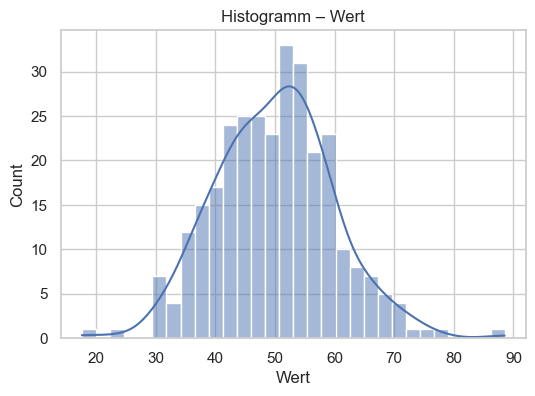

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(df["Wert"], kde=True, bins=30)
plt.title("Histogramm – Wert")
plt.show()

## 7.2 Boxplot

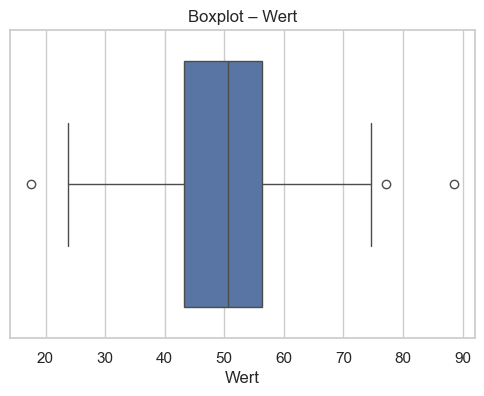

In [62]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Wert"])
plt.title("Boxplot – Wert")
plt.show()

## 7.3 Scatterplot

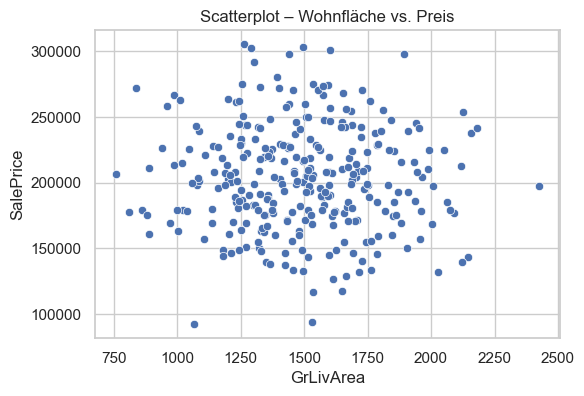

In [63]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["GrLivArea"], y=df["SalePrice"])
plt.title("Scatterplot – Wohnfläche vs. Preis")
plt.show()

## 7.4 Heatmap

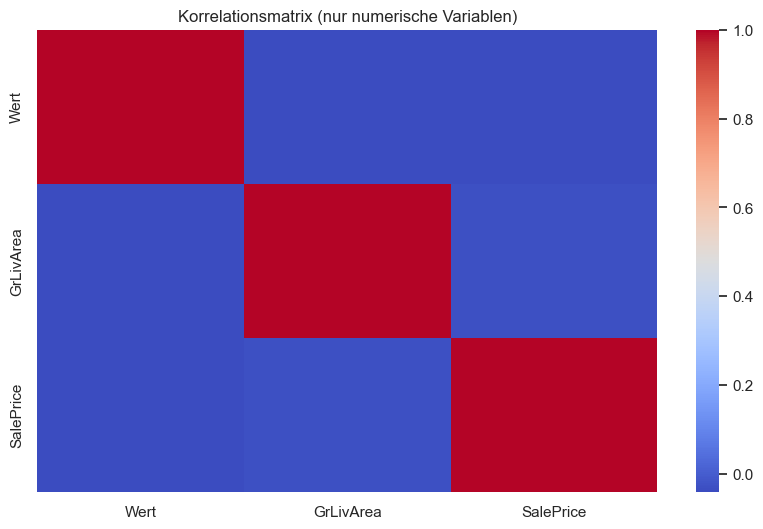

In [70]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Nur numerische Spalten auswählen
df_numeric = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(df_numeric.corr(), cmap="coolwarm", annot=False)
plt.title("Korrelationsmatrix (nur numerische Variablen)")
plt.show()

# 📐 8. Standardisierung & z‑Werte

## 8.1 z‑Wert eines einzelnen Wertes

In [65]:
x = df["Wert"]
mu = x.mean()
sigma = x.std(ddof=1)

z = (x - mu) / sigma
z.head()

0    0.510329
1   -0.134847
2    0.663728
3    1.553128
4   -0.232276
Name: Wert, dtype: float64

## 8.2 z‑Werte → Normalverteilung

In [66]:
# P(Z < 1.96)
norm.cdf(1.96)

# P(|Z| < 1.96)
2 * norm.cdf(1.96) - 1

# Dichte f(x)
norm.pdf(0)

np.float64(0.3989422804014327)

# 🎲 9. Wahrscheinlichkeitsverteilungen

## 9.1 Binomialverteilung

In [67]:
# P(X = 3) bei n=10, p=0.4
binom.pmf(3, n=10, p=0.4)

np.float64(0.21499084799999976)

## 9.2 Hypergeometrische Verteilung

In [68]:
hypergeom.pmf(2, M=5, N=50, n=10)

np.float64(nan)

## 9.3 χ²‑Verteilung

In [69]:
chi2.pdf(3, df=5)

np.float64(0.15418032980376928)